In [32]:
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_percentage_error


# For 2D analysis
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
# from utils import period2freq, freq2period

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import csv
import time
import glob

# Datasize in KB
data_size_kb = {'4mb': 4096, '16mb': 16384, '64mb': 65536,
            '256mb': 262144, '512mb': 524288, '1gb': 1048576,
            '5gb': 5242880, '50gb': 52428800, '100gb': 104857600,
            '300gb': 314572800,}

# Key Parameters
IOR_PARAMS = ['operation', 'randomOffset', 'transferSize', 
            'aggregateFilesizeMB', 'numTasks', 'totalTime', 
            'numNodes', 'tasksPerNode', 'bwMiB', "storageType"]

TARGET_PARAMS = [ "bestStorage" ]
op_dict = {0: "write", 1: "read"}


## Bandwidth Prediction from IOR to Workflow
### Key parameters from IOR
Parameters for emulation:
- D: Total I/O size per task per operation (take log scale)
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: Bandwidth calculated from TIO/T
### Special note for IOR
IOR calculates bwMiB, but the bwMiB is little slower than the (aggregate filesize)/totalTime, but not much difference, particularly in the `totalTime=openTimewrRdTime+closetime`

### Key parameters from workflow
Parameters for characteristics
- D: Total I/O size per task per operation (take log scale)
- C: Total I/O operation count per operation type, [Cr, Cw]
- A: Average I/O size per operation type, calculate from A=D/C [Ar, Aw]
- IOT: I/O opeartion type per task (seq/ran, read/write), [OTsr, OTsw, OTrr, OTrw]
- N: Number of parallelism/tasks 
- OSC: Size of OS buffered cache
- Mem: Size of memory
Parameters for prediciton:
- TIO: Total I/O size for all tasks
- T: Time spend on the type of I/O operation per task, [Tr, Tw]
- BW: Bandwidth calculated from TIO/T

### Perf Modeling Parameters
- a: Performance change when total data size reaches memory buffer cache of system.
- b: Performance change when  total data size reaches memory size of system. (Constant value)
- v: Performance variation due to shared storage resource. 
(The peak variation in the system. Measure with IOR.)
Deception BeeGFS: run at off hour to keep below 20% variation.
Options: (1) User/system admin to ensure the variation percentage; 
(2) Obtain variation with IOR emulation (possible over 20%)
- r: Range of expected performance: Make correct choice with given storage options.
- LPMR: Layered performance matching number for comparing application storage choice.
- w: Weight of a application LPMR. (Total data size, cost of moving data)



# TODO
- normalize BW differently! use same log scale for all (DONE)
- BeeGFS graph show variance:
    - identify whether the performance changes is due to BeeGFS parameters or due to traffic
    - parameter: distribution, tell us the load at particular time, background traffic under a percentage 5%, parameter it self can be a range.
    - Microbenchmark on background load, in principle that we know this exists and we assume we know a load factor, adjust the results. Whether it affect the storage choice for a type of workload.
    

In [33]:
def byte_size_to_human_size(byte_size):
    if byte_size < 1024:
        return f"{byte_size} B"
    elif byte_size < 1024**2:
        return f"{byte_size/1024} KiB"
    elif byte_size < 1024**3:
        return f"{byte_size/1024**2} MiB"
    elif byte_size < 1024**4:
        return f"{byte_size/1024**3} GiB"
    else:
        return f"{byte_size/1024**4} TiB"

def file_size_to_mb(file_size):
    # If file_size is type string, convert to float
    if type(file_size) == str:
        # Translate KiB, MiB, and GiB to bytes
        size_num = float(file_size.split(" ")[0])
        size_unit = file_size.split(" ")[1]
        if size_unit == "KiB":
            return float(size_num/1024)
        elif size_unit == "MiB":
            return float(size_num)
        elif size_unit == "GiB":
            return float(size_num * 1024)
        else:
            # If file_size is type int, convert to MB
            return int(size_num/1024**2)
    else:
        # If file_size is type int, convert to MB
        return int(file_size/1024**2)

def transform_store_code(storage_type):
    if storage_type == "localssd":
        store_code = 0
    elif storage_type == "beegfs":
        store_code = 1
    elif storage_type == "lustre":
        store_code = 2
    else:
        store_code = 3
    return store_code

def decode_store_code(store_code):
    if store_code == 0:
        storage_type = "localssd"
    elif store_code == 1:
        storage_type = "beegfs"
    elif store_code == 2:
        storage_type = "lustre"
    else:
        storage_type = "unknown"
    return storage_type

def get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS):


    # Create a dataframe for storing ior parameters
    ior_df = pd.DataFrame(columns=IOR_PARAMS)
    store_code = transform_store_code(storage_type)

    # Load Json files
    for jfile in ior_test_json_files:
        with open(jfile) as f:
            try:
                data = json.load(f)
            except:
                print("Error reading file: ", jfile)
                continue
            # print(jfile)
            
            # Write then Read
            ior_options = data['tests'][0]["Options"]
            IOR_PARAMS = data['tests'][0]["Parameters"]

            # Add write statistics first
            if file_size_to_mb(ior_options['aggregate filesize']) != 0:
                tmp_write_stat = {}
                ior_write_summary = data['summary'][0]
                # check if ior_write_summary is empty
                if ior_write_summary:
                    tmp_write_stat['randomOffset'] = IOR_PARAMS['randomOffset']
                    tmp_write_stat['aggregateFilesizeMB'] = file_size_to_mb(ior_options['aggregate filesize'])
                    tmp_write_stat['numTasks'] = ior_write_summary['numTasks']
                    tmp_write_stat['tasksPerNode'] = ior_write_summary['tasksPerNode']
                    tmp_write_stat['numNodes'] = tmp_write_stat['numTasks']/tmp_write_stat['tasksPerNode']
                    tmp_write_stat['transferSize'] = ior_write_summary['transferSize']
                    if ior_write_summary['operation'] == "write":
                        tmp_write_stat['operation'] = 0
                    else:
                        tmp_write_stat['operation'] = -1
                    tmp_write_stat['totalTime'] = ior_write_summary['MeanTime'] # only 1 operation per test
                    tmp_write_stat['bwMiB'] = ior_write_summary['bwMeanMIB'] # only 1 operation per test
                    tmp_write_stat['storageType'] = store_code
                    # Add tmp_write_stat to df
                    ior_df = ior_df._append(tmp_write_stat, ignore_index=True)
                else:
                    print("WARNING: Empty write summary")

                # Add read statistics
                tmp_read_stat = {}
                ior_read_summary = data['summary'][1]
                # check if ior_read_summary is empty
                if ior_read_summary:
                    tmp_read_stat['randomOffset'] = IOR_PARAMS['randomOffset']
                    tmp_read_stat['aggregateFilesizeMB'] = file_size_to_mb(ior_options['aggregate filesize'])
                    tmp_read_stat['numTasks'] = ior_read_summary['numTasks']
                    tmp_read_stat['tasksPerNode'] = ior_read_summary['tasksPerNode']
                    tmp_read_stat['numNodes'] = tmp_read_stat['numTasks']/tmp_read_stat['tasksPerNode']
                    tmp_read_stat['transferSize'] = ior_read_summary['transferSize']
                    if ior_read_summary['operation'] == "read":
                        tmp_read_stat['operation'] = 1
                    else:
                        tmp_read_stat['operation'] = -1
                    tmp_read_stat['totalTime'] = ior_read_summary['MeanTime']
                    tmp_read_stat['bwMiB'] = ior_read_summary['bwMeanMIB']
                    tmp_read_stat['storageType'] = store_code
                    # Add tmp_read_stat to df
                    ior_df = ior_df._append(tmp_read_stat, ignore_index=True)
                else:
                    print("WARNING: Empty read summary")

    # encode string to numbers
    le = preprocessing.LabelEncoder()
    for col in ior_df.columns:
        if pd.api.types.is_string_dtype(ior_df[col]):
            ior_df[col] = le.fit_transform(ior_df[col])

    # print(ior_df.head(5))

    return ior_df

def plot_heatmap(corrM,outfile):
    plt.figure(figsize=(14, 8))
    #labels = list(corrM.columns)
    plt.subplots_adjust(bottom=0.19)

    # # use only lower triangle
    # corrM = corrM.where(np.triu(np.ones(corrM.shape)).astype(np.bool))

    ## plot all correlation heatmap
    map = sns.heatmap(corrM, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='grey', cmap='BrBG') #annot=True,
    map.set_title('Correlation Matrix Heatmap', fontdict={'fontsize':12}, pad=12)
    #plt.show()
    out_file=f'{outfile}.png'
    plt.savefig(out_file)
    plt.clf()

def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop
    
def corrM_sorted_csv(corrM, outfile):
  n=5
  au_corr = corrM.corr().abs().unstack()
  labels_to_drop = get_redundant_pairs(corrM)
  au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
  sorted_corrM = au_corr[0:n]

  out_file= outfile
  sorted_corrM.to_csv(out_file)

def corr_matrix(df,outname=""):

    # calculte correlation matrix
    corrM = df.corr()

    corrM.to_csv(f'{outname}.csv')
    plot_heatmap(corrM,outname)
    #corrM_sorted_csv(corrM, f'sorted_{outname}.csv')

def _2d_trend(X, y, x_label="x-axis", y_label="bwMiB", title="", show=False):
        # X = X.reshape(-1, 1)
        X = X.values.reshape(-1, 1)
        # poly = PolynomialFeatures(degree=2)
        poly = PolynomialFeatures(degree=1)
        poly_data = poly.fit_transform(X)
        model = LinearRegression()
        model.fit(poly_data,y)
        coef = model.coef_
        intercept = model.intercept_
        # Set figure size (80,50)
        plt.figure(figsize=(10,5))

        plt.scatter(X,y,color='red')
        plt.plot(X,model.predict(poly.fit_transform(X)),color='blue')
        # Show the fit parameters on graph with scientific notation
        plt.annotate(f"y = {coef[1]:.2e}x + {intercept:.2e}", xy=(0.05, 0.95), xycoords='axes fraction')

        # print(f"y = {coef[1]}x + {intercept}")
        plt.legend(['Original','Prediction'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        if show:
            plt.show()
        return coef[1], intercept

def _3d_trend(x,y,z, title=""):
    # ref: https://stackoverflow.com/questions/2298390/fitting-a-line-in-3d
    # Convert Pandas Series to NumPy arrays
    x = x.to_numpy()
    y = y.to_numpy()
    z = z.to_numpy()
    
    data = np.concatenate((x[:, np.newaxis], 
                        y[:, np.newaxis], 
                        z[:, np.newaxis]), 
                        axis=1)
    
    data = data.astype('float64')

    # Calculate the mean of the points, i.e. the 'center' of the cloud
    datamean = data.mean(axis=0)
    print(datamean)

    # Do an SVD on the mean-centered data.
    # full_matrices=False reduce memory
    uu, dd, vv = np.linalg.svd(data - datamean, full_matrices=False)

    # Get the sptread of data with mean 0 from all axis
    x_min = np.min(data[:,0])
    y_min = np.min(data[:,1])
    z_min = np.min(data[:,2])

    x_max = np.max(data[:,0])
    y_max = np.max(data[:,1])
    z_max = np.max(data[:,2])

    low_bound = min(x_min, y_min, z_min)
    high_bound = max(x_max, y_max, z_max)

    # Now vv[0] contains the first principal component, i.e. the direction
    # vector of the 'best fit' line in the least squares sense.
    # Adjust axist limits (Optional)
    linepts = vv[0] * np.mgrid[low_bound:high_bound:2j][:, np.newaxis]
    # shift by the mean to get the line in the right place
    linepts += datamean

    # Verify that everything looks right.

    # import mpl_toolkits.mplot3d as m3d
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter3D(*data.T)
    ax.plot3D(*linepts.T)
    # ax.scatter3D(data[:,0], data[:,1], data[:,2])
    ax.set_xlabel("transferSize")
    ax.set_ylabel("aggregateFilesizeMB")
    ax.set_zlabel("bwMiB")
    ax.set_title(title)
    plt.show()



In [34]:

def _polynomial_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Define a polynomial function to fit
    def polynomial_func(x, a, b, c):
        return a * x**2 + b * x + c

    # Fit the polynomial curve
    params, _ = curve_fit(polynomial_func, pca_df['PC1'], pca_df['PC2'])

    # Predict values using the fitted curve
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_curve = polynomial_func(x_vals, *params)

    # Visualizing the PCA result and the fitted curve
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_curve, color='red', label='Polynomial Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Curve fit parameters
    print(f'Polynomial fit parameters: a={params[0]}, b={params[1]}, c={params[2]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')


def _linear_fit_pca(df, title):
    # Standardizing the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Performing PCA
    pca = PCA(n_components=2)  # Reduce to 2 components for visualization
    principal_components = pca.fit_transform(scaled_data)

    # Creating a DataFrame with the principal components
    pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # Fit the linear regression model
    reg = LinearRegression()
    reg.fit(pca_df[['PC1']], pca_df['PC2'])

    # Predict values using the fitted model
    x_vals = np.linspace(pca_df['PC1'].min(), pca_df['PC1'].max(), 100)
    fitted_line = reg.predict(x_vals.reshape(-1, 1))

    # Visualizing the PCA result and the fitted line
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='PC1', y='PC2', data=pca_df, label='PCA Data')
    plt.plot(x_vals, fitted_line, color='red', label='Linear Fit')
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

    # Linear fit parameters
    print(f'Linear fit parameters: intercept={reg.intercept_}, slope={reg.coef_[0]}')

    # Reconstructing the data from the principal components
    reconstructed_data = pca.inverse_transform(principal_components)

    # Calculating the reconstruction error
    mse = mean_squared_error(scaled_data, reconstructed_data)
    print(f'Reconstruction error (MSE): {mse}')

    # Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f'Explained variance by principal components: {explained_variance}')


def ior_json_to_df(ior_data_path):
    # Get the list of JSON files from the directory
    ior_test_json_files = glob.glob(ior_data_path + "/*.json")

    # Get storage type from data_path name
    # storage_type =  ior_data_path.split("/")[-1].split("_")[0] + "_" + ior_data_path.split("/")[-1].split("_")[1]
    storage_type =  ior_data_path.split("/")[-1].split("_")[0]
    # print("Storage Type: ", storage_type)
    ior_df = get_ior_json_df(ior_test_json_files, storage_type, IOR_PARAMS)

    # corr_matrix(ior_df, storage_type)

    return ior_df

# Take a column name for y_data
def x_mean_std(group, y_column):
    return pd.Series({
        f'{y_column}_ave': group[y_column].mean(),
        f'{y_column}_ave_std': group[y_column].std(ddof=0)  # Use population standard deviation by setting ddof=0
    })

from sklearn.preprocessing import MinMaxScaler
def my_data_transform(df, cols_to_norm=[], cols_to_log=[]):
    # Create an empty DataFrame to store the results
    results = []

    # Get unique transfer sizes and number of tasks
    xfersizes = sorted(df['transferSize'].unique())
    numTasks = sorted(df['numTasks'].unique())
    op_type = [0, 1]  # Define outside the loop to avoid redefinition
    print("Transfer Sizes: ", xfersizes)
    print("Number of Tasks: ", numTasks)

    for xfer in xfersizes:
        for t in numTasks:
            for op in op_type:
                # Filter the DataFrame for specific conditions
                subdf = df[(df['numTasks'] == t) &
                           (df['transferSize'] == xfer) &
                           (df['operation'] == op)].copy()
                
                if not subdf.empty:
                    # Calculate the mean and standard deviation of the bwMiB column
                    ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
                        lambda group: x_mean_std(group, 'bwMiB')
                    ).reset_index()

                    # Calculate percentage of standard deviation
                    ave_bw_df['bwMiB_ave_std_perc'] = (ave_bw_df['bwMiB_ave_std'] /
                                                       ave_bw_df['bwMiB_ave']) * 100

                    # Merge the aggregated results with the original DataFrame
                    merged_df = pd.merge(subdf, ave_bw_df, on='aggregateFilesizeMB', how='left')

                    # Append the merged DataFrame to the results list
                    results.append(merged_df)

    # Concatenate all the DataFrames in the results list
    new_df = pd.concat(results, ignore_index=True)

    # Log transformation
    if cols_to_log:
        log_new_cols = [f"{col}_log" for col in cols_to_log]
        print("Columns to log: ", cols_to_log)
        new_df[log_new_cols] = np.log(new_df[cols_to_log])

    # Min-Max normalization
    if cols_to_norm:
        norm_new_cols = [f"{col}_norm" for col in cols_to_norm]
        print("Columns to normalize: ", cols_to_norm)
        scaler = MinMaxScaler()
        new_df[norm_new_cols] = scaler.fit_transform(new_df[cols_to_norm])

    return new_df

def oscillatory_func(x, amplitude, frequency, phase, offset):
    return amplitude * np.sin(frequency * x + phase) + offset

def damped_sine_func(x, amplitude, frequency, phase, offset, decay):
    return amplitude * np.sin(frequency * x + phase) * np.exp(-decay * x) + offset

def cos_func(x, amplitude, frequency):
    return amplitude * np.cos(frequency * x)

def normalize_y(y_data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    return scaler.fit_transform(y_data.values.reshape(-1, 1)).flatten()

def _oscillatory_trend(x_data, y_data, x_label="x-axis", y_label="bwMiB", title="", 
                       show=False, x_datalabel=[], y_datalabel=[], save_path=""):
    # Normalize y_data
    y_data_normalized = y_data #normalize_y(y_data)
    
    # Initial guess for the parameters
    amplitude_guess = (np.max(y_data_normalized) - np.min(y_data_normalized)) / 2
    frequency_guess = 10
    if y_data_normalized[1] > y_data_normalized[0]:
        phase_guess = 0
    else:
        phase_guess = np.pi
    offset_guess = np.mean(y_data_normalized)
    initial_guess = [amplitude_guess, frequency_guess, phase_guess, offset_guess]

    try:
        # Fit the oscillatory function to the normalized data
        params, params_covariance = curve_fit(oscillatory_func, x_data, y_data_normalized, p0=initial_guess, maxfev=10000)
        # params, params_covariance = curve_fit(cos_func, x_data, y_data_normalized, p0=(amplitude_guess, frequency_guess), maxfev=10000)
    except RuntimeError as e:
        print(f"Sine wave fitting failed: {e}")
        # Attempt to fit a damped sine wave if the initial fit fails
        decay_guess = 0.1
        frequency_guess = 20
        # phase_guess2 = 1
        phase_guess = np.pi
        updated_guess = [amplitude_guess, frequency_guess, phase_guess, offset_guess]
        try:
            params, params_covariance = curve_fit(oscillatory_func, x_data, y_data_normalized, p0=initial_guess, maxfev=10000)
        except RuntimeError as e:
            print(f"Sine wave re-fitting failed: {e}")
            return

    # Print the fitted parameters
    print("Fitted parameters:", params)

    # Generate y values based on the fitted parameters
    if len(params) == 4:
        y_fitted = oscillatory_func(x_data, *params)
        equation = f"y = {params[0]:.2f} * sin({params[1]:.2e}x + {params[2]:.2e}) + {params[3]:.2e}"
    else:
        y_fitted = damped_sine_func(x_data, *params)
        equation = f"y = {params[0]:.2f} * sin({params[1]:.2e}x + {params[2]:.2e}) * exp(-{params[4]:.2e}x) + {params[3]:.2e}"

    # set figure size
    plt.figure(figsize=(10,5))

    # Plot the original data as a scatter plot
    plt.scatter(x_data, y_data_normalized, label='Data')

    # Plot the fitted oscillatory curve
    plt.plot(x_data, y_fitted, color='red', label='Fitted Curve')

    # Add data labels foreach point
    x_label_list = []
    y_label_list = []
    if len(x_datalabel) == len(x_data):
        for i, label in enumerate(x_datalabel):
            x_label_list.append(label)
    if len(y_datalabel) == len(y_data):
        for i, label in enumerate(y_datalabel):
            y_label_list.append(label)
    for i in range(len(x_data)):
        plt.text(x_data[i], y_data_normalized[i], f"{x_label_list[i]}, {y_label_list[i]}", fontsize=8, ha='left', va='bottom')
    
    # Always plot x and y from 0 to 1
    plt.xlim(0, 1)
    # plt.ylim(0, 1)

    # Add labels and legend
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if title:
        plt.title(title)
    else:
        plt.title('Scatter Plot with Curve Fit')
    plt.legend()
    
    # Write the equation of the fitted curve on the plot
    plt.annotate(equation, xy=(0.05, 0.25), xycoords='axes fraction')
    # Add phase_guess and frequency_guess to the plot
    plt.annotate(f"Phase: {params[2]:.2e}, Frequency: {params[1]:.2e}", xy=(0.05, 0.20), xycoords='axes fraction')

    if show:
        # Show the plot
        plt.show()
    
    if save_path != "":
        # save with plt title
        plt.savefig(f'{save_path}/{title}.png')



In [35]:
ior_ssd_data_paths = [
        "./ior_data/localssd_ior_buffered_saved",
    "./ior_data/localssd_pior_buffered_saved",
]

ior_beegfs_data_paths = [
    "./ior_data/beegfs_ior_buffered_saved",
    "./ior_data/beegfs_pior_buffered_saved",
]




def data_paths_to_df(ior_data_paths):
    path_ior_df = pd.DataFrame(columns=IOR_PARAMS)

    for ior_data_path in ior_data_paths:
        ior_df = ior_json_to_df(ior_data_path)
        path_ior_df = path_ior_df._append(ior_df, ignore_index=True)

    cols_to_log = ['aggregateFilesizeMB', 'transferSize'] # , 'transferSize'
    cols_to_norm = ['aggregateFilesizeMB_log', 'bwMiB'] # 'transferSize', 'bwMiB'
    # normalize data
    scaled_ior_df = my_data_transform(path_ior_df, cols_to_norm=cols_to_norm, cols_to_log=cols_to_log)

    return scaled_ior_df

ssd_df = data_paths_to_df(ior_ssd_data_paths)
beegfs_df = data_paths_to_df(ior_beegfs_data_paths)

print(ssd_df.head(5))
print(beegfs_df.head(5))



/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/1779098759.py:95: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ior_df = ior_df._append(tmp_write_stat, ignore_index=True)
/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3911546091.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  path_ior_df = path_ior_df._append(ior_df, ignore_index=True)
/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/1779098759.py:95: FutureWarning: The behavior of DataFram

Transfer Sizes:  [np.float64(64.0), np.float64(1024.0), np.float64(4096.0), np.float64(1048576.0), np.float64(4194304.0), np.float64(16777216.0), np.float64(67108864.0), np.float64(268435456.0), np.float64(1073741824.0)]
Number of Tasks:  [np.float64(1.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0)]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3635682325.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3635682325.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
/var/folders/t1/j5nks1f97pzdzx63f2_4_6

Columns to log:  ['aggregateFilesizeMB', 'transferSize']
Columns to normalize:  ['aggregateFilesizeMB_log', 'bwMiB']


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3911546091.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  path_ior_df = path_ior_df._append(ior_df, ignore_index=True)
/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/1779098759.py:95: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ior_df = ior_df._append(tmp_write_stat, ignore_index=True)


Transfer Sizes:  [np.float64(64.0), np.float64(1024.0), np.float64(4096.0), np.float64(1048576.0), np.float64(4194304.0), np.float64(16777216.0), np.float64(67108864.0), np.float64(268435456.0), np.float64(1073741824.0)]
Number of Tasks:  [np.float64(1.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0)]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3635682325.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3635682325.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
/var/folders/t1/j5nks1f97pzdzx63f2_4_6

Columns to log:  ['aggregateFilesizeMB', 'transferSize']
Columns to normalize:  ['aggregateFilesizeMB_log', 'bwMiB']
   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        0.0           0.0          64.0               1024.0       1.0   
1        0.0           0.0          64.0               5120.0       1.0   
2        0.0           0.0          64.0              51200.0       1.0   
3        0.0           0.0          64.0               1024.0       1.0   
4        0.0           0.0          64.0                256.0       1.0   

   totalTime  numNodes  tasksPerNode    bwMiB  storageType  bwMiB_ave  \
0    19.2664       1.0           1.0  53.1495          0.0  52.863400   
1    95.7673       1.0           1.0  53.4629          0.0  53.081333   
2   990.6863       1.0           1.0  51.6813          0.0  51.160300   
3    19.2578       1.0           1.0  53.1734          0.0  52.863400   
4     4.8504       1.0           1.0  52.7788          0.0  52.8241

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3635682325.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3635682325.py:137: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB').apply(
/var/folders/t1/j5nks1f97pzdzx63f2_4_6

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 0.01688571  0.05908136  1.54936168 -0.01687616]


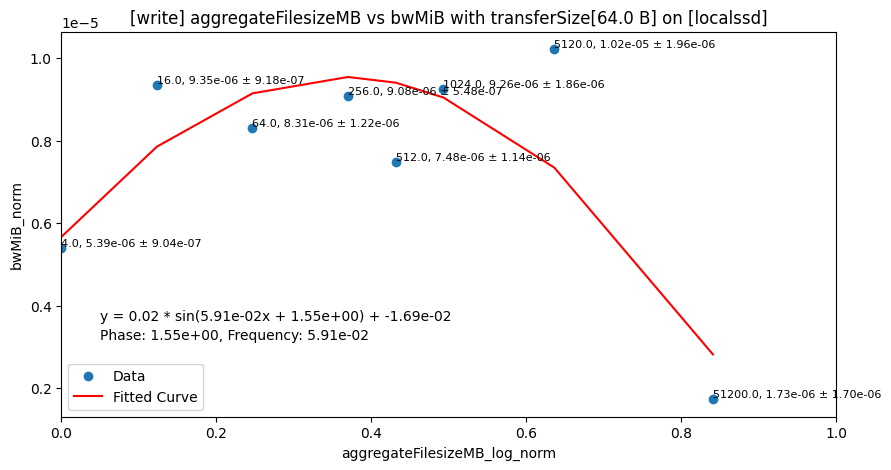

Fitted parameters: [-4.82709347e-06  1.39223923e+01 -2.83722794e+00  3.88699427e-04]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

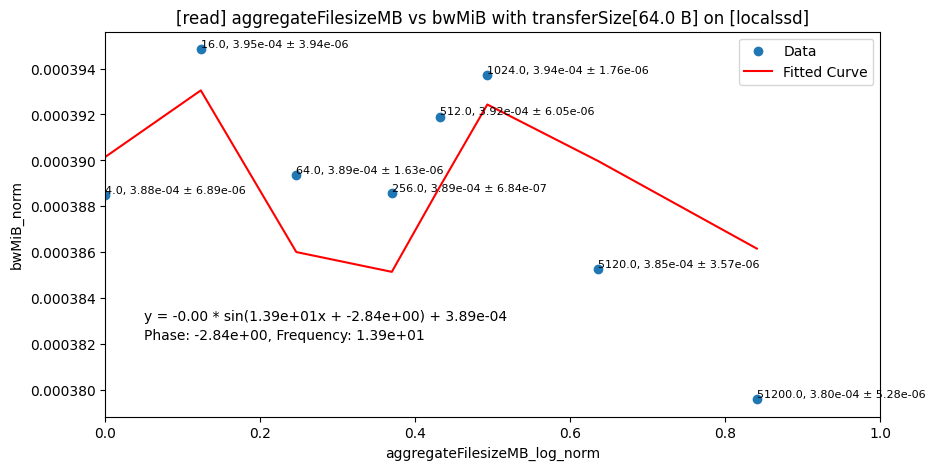

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 1.20860848e-04  1.07414299e+01 -1.89816753e+00  1.74388678e-03]


<Figure size 640x480 with 0 Axes>

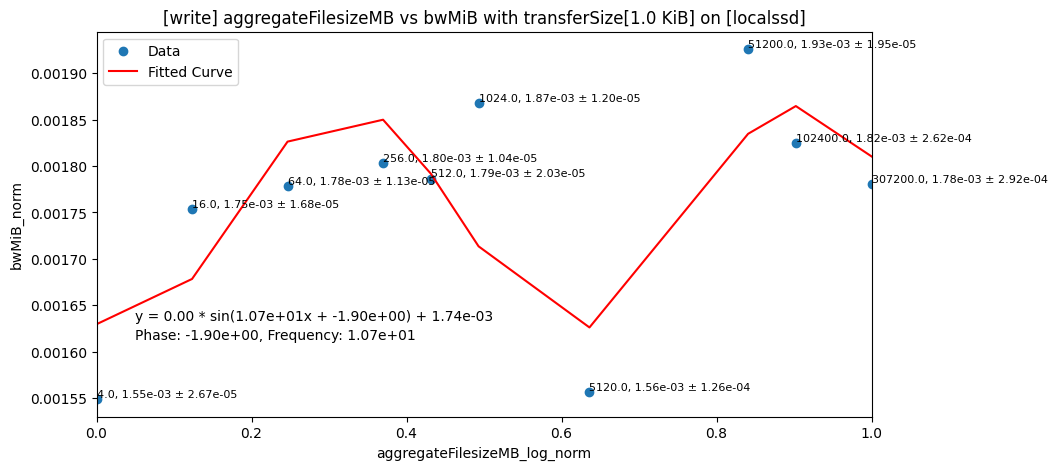

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [6.28641377e-04 1.49158487e+01 2.32345112e+00 8.59397431e-03]


<Figure size 640x480 with 0 Axes>

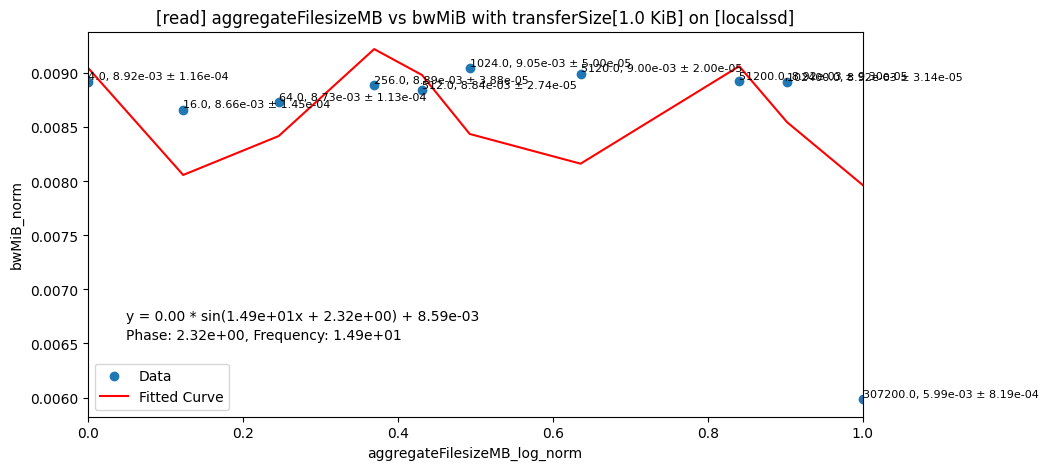

Fitted parameters: [-5.53071623e-04  5.59747600e+00  2.81480715e+00  2.73781384e-03]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

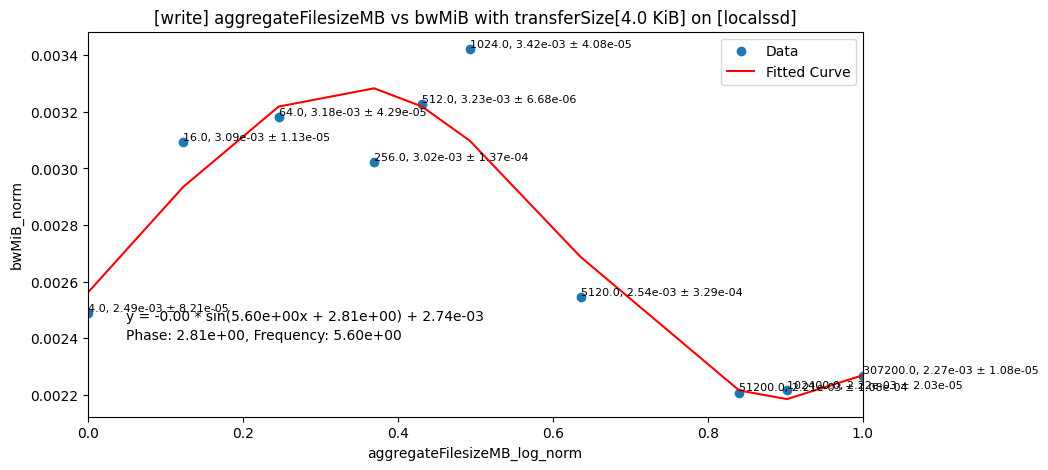

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [4.75855719e-03 9.24802419e+00 1.88600750e+00 2.15675631e-02]


<Figure size 640x480 with 0 Axes>

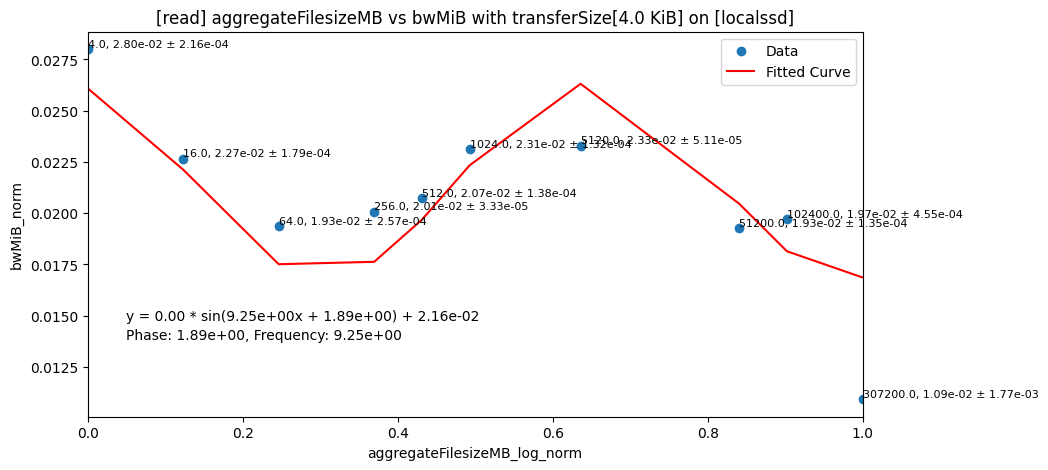

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [-9.23195657e-04  5.35551221e+00  2.99410050e+00  3.14679700e-03]


<Figure size 640x480 with 0 Axes>

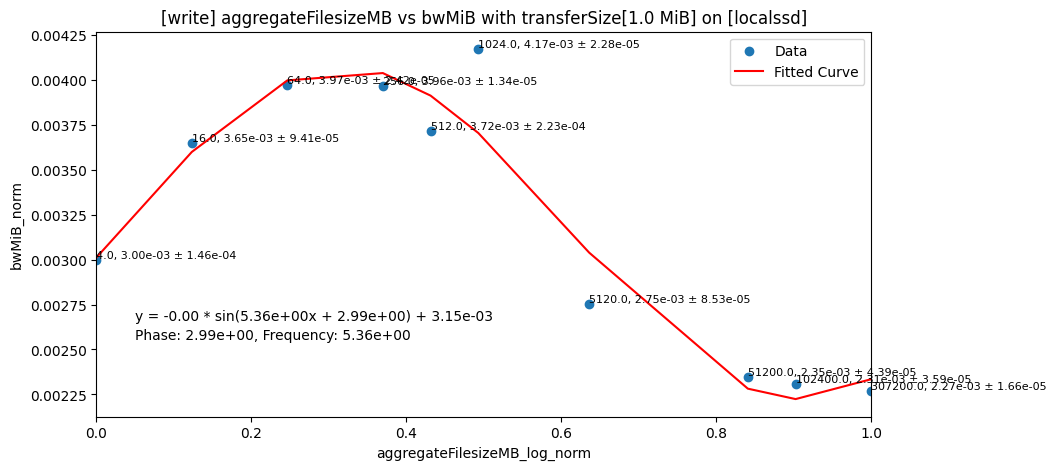

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [0.00933543 8.6452697  2.43506968 0.0344746 ]


<Figure size 640x480 with 0 Axes>

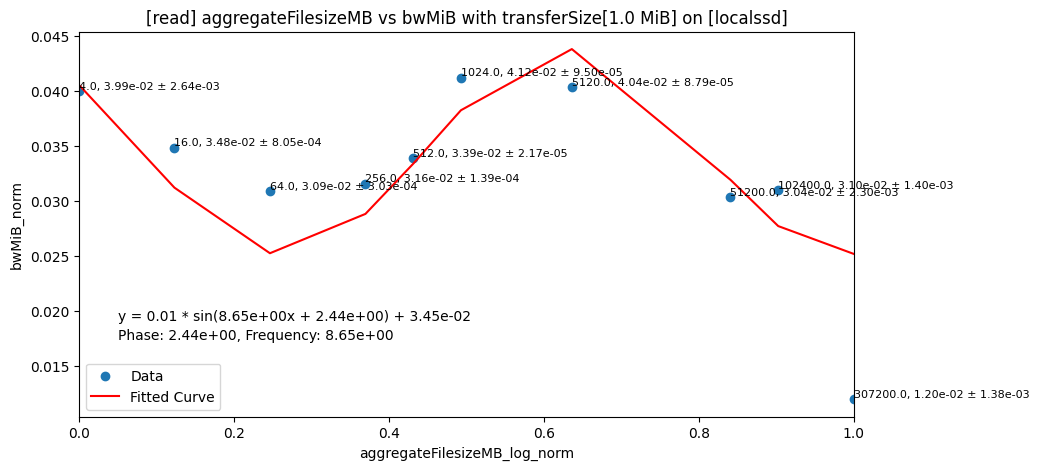

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 4.21939784  0.08381456 10.92471519  4.22105386]


<Figure size 640x480 with 0 Axes>

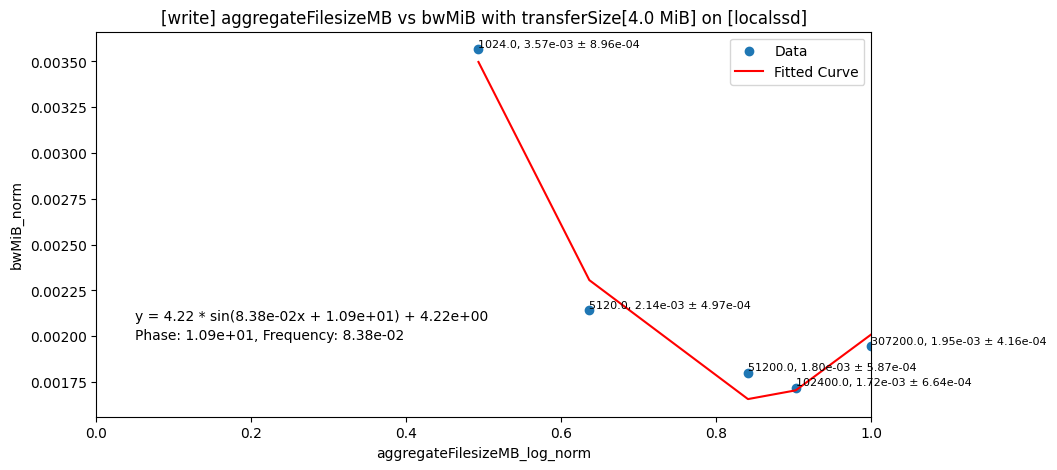

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 64.43661106   0.06695846   7.81535055 -64.39401831]


<Figure size 640x480 with 0 Axes>

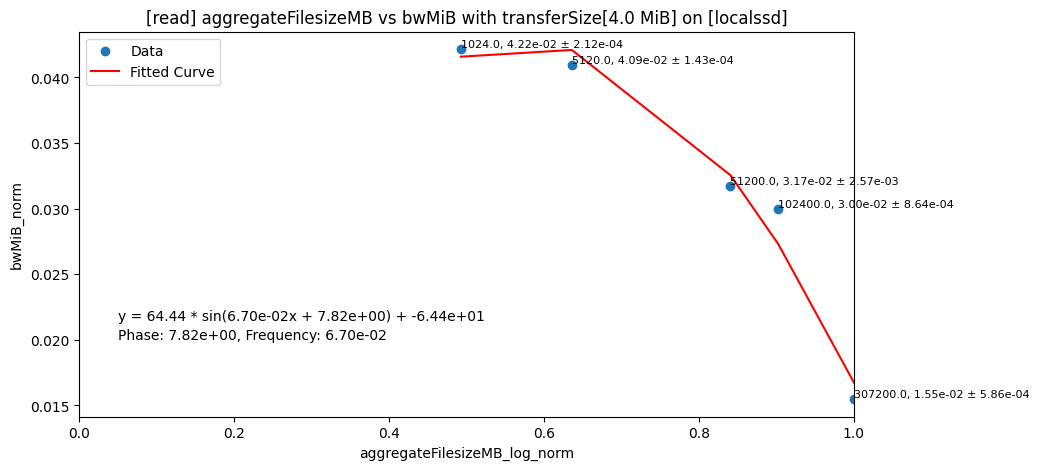

Fitted parameters: [ 5.70714027  0.0798681  10.9309802   5.7090547 ]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

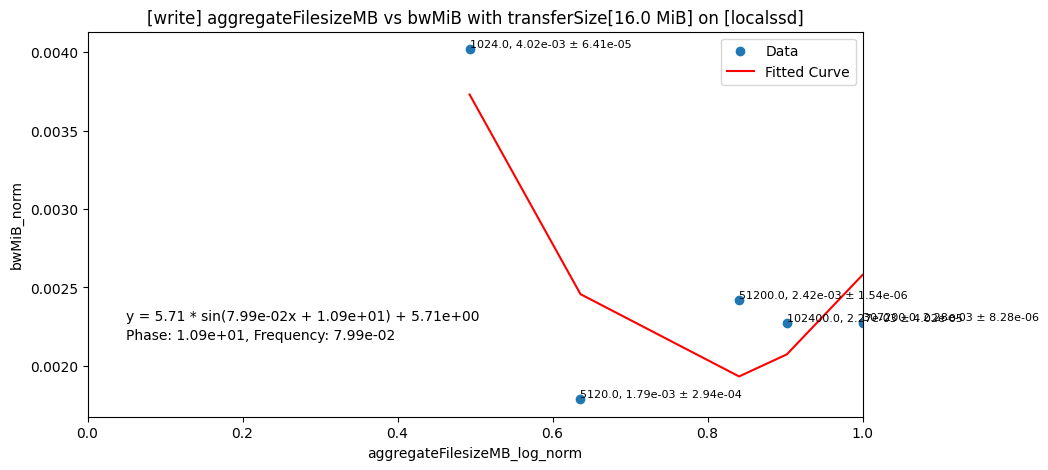

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 7.14678513e+01  6.59016953e-02  7.81310300e+00 -7.14297275e+01]


<Figure size 640x480 with 0 Axes>

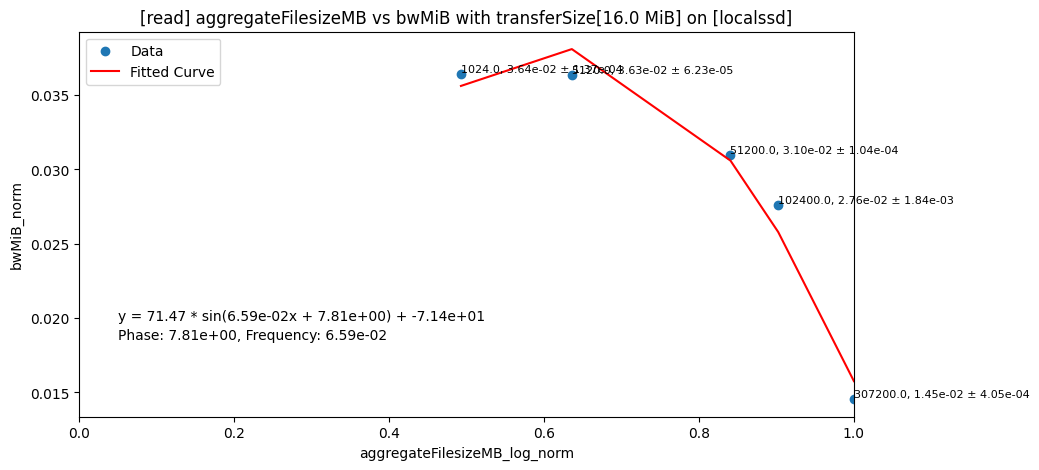

Fitted parameters: [ 5.26877363  0.07090588 10.9347915   5.27095239]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

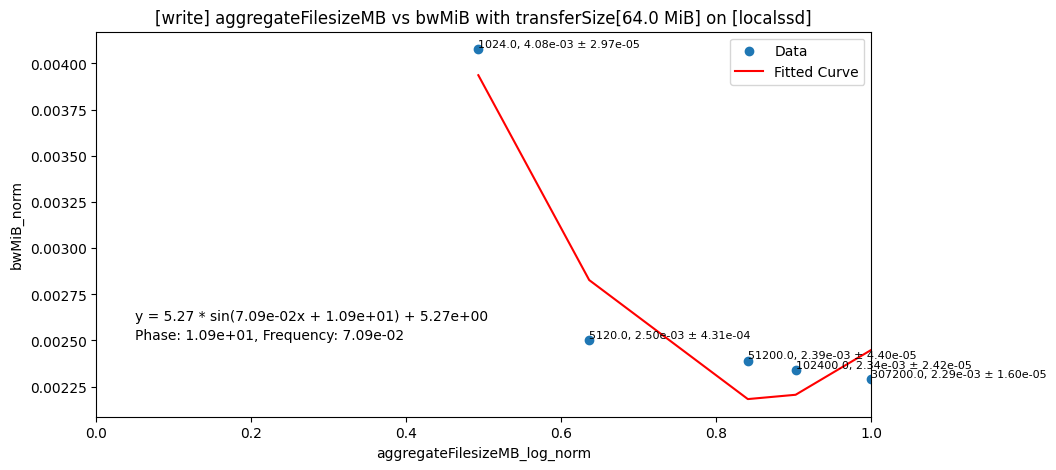

Fitted parameters: [2.65018893e-02 2.91387480e+00 6.13631400e+00 1.91509768e-03]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

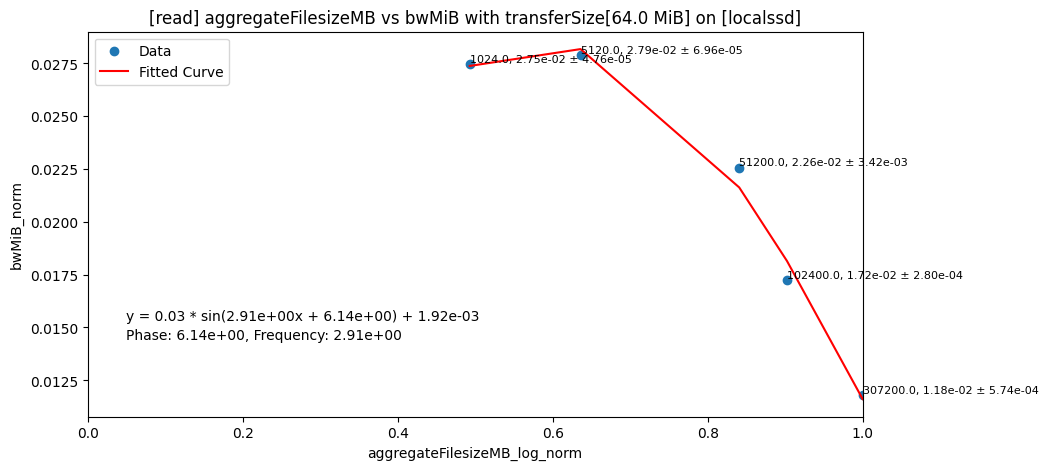

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 1.45313169  0.06501421 10.93413107  1.45546801]


<Figure size 640x480 with 0 Axes>

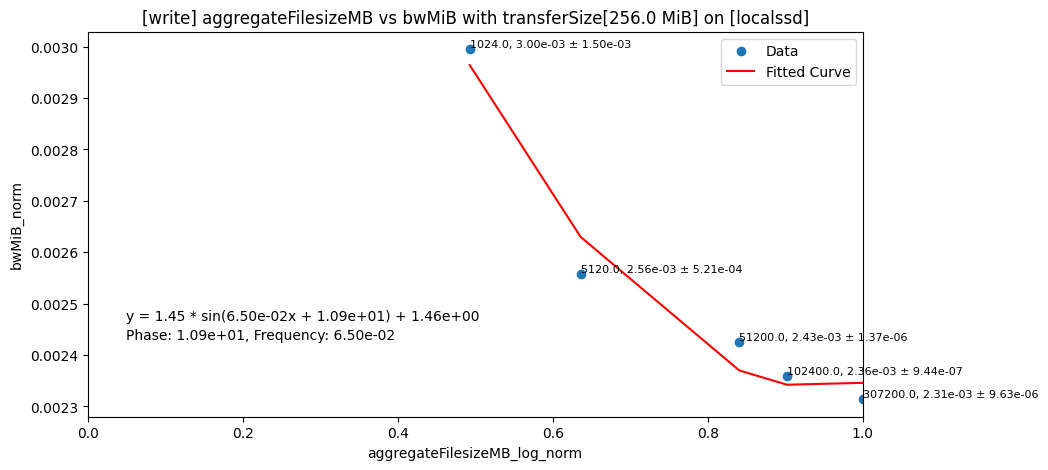

Fitted parameters: [ 6.90793977e-03  1.85918810e+01 -8.92411449e+00  1.98254692e-02]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

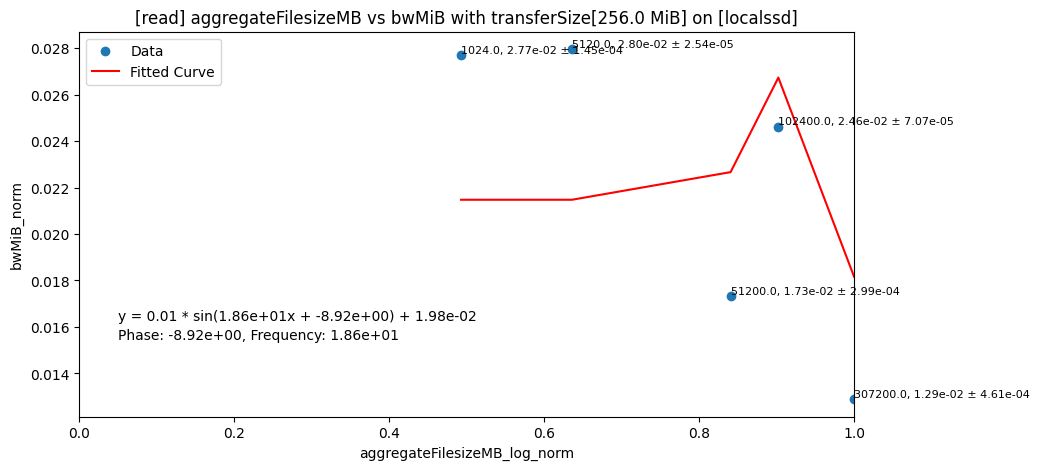

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 3.9651795   0.06797098 10.93318355  3.96747977]


<Figure size 640x480 with 0 Axes>

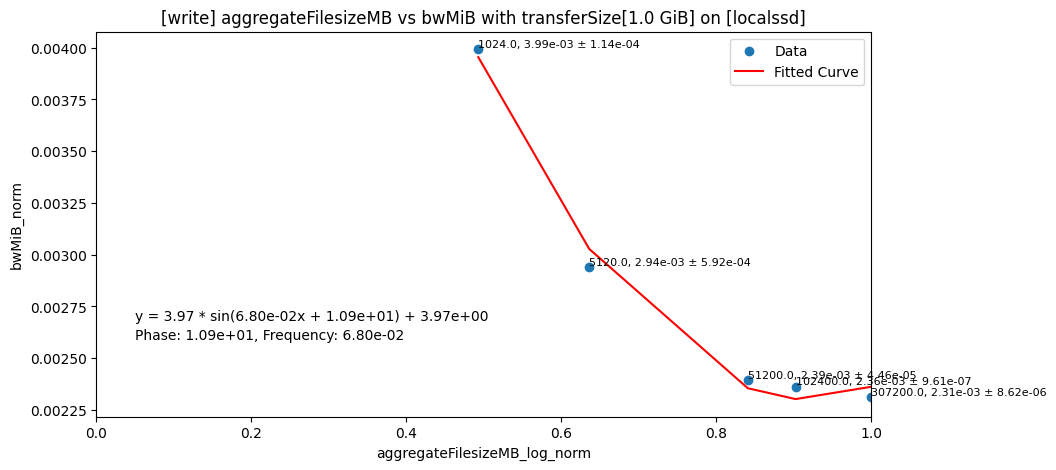

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 17.35401482   0.09012222   7.80375961 -17.32615051]


<Figure size 640x480 with 0 Axes>

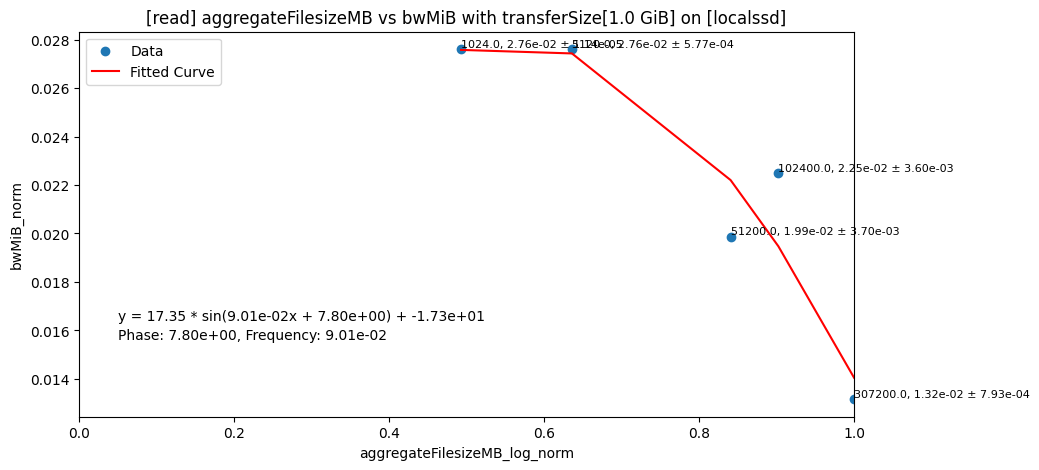

Fitted parameters: [ 8.97722742  0.09243314  1.54174169 -8.97103531]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

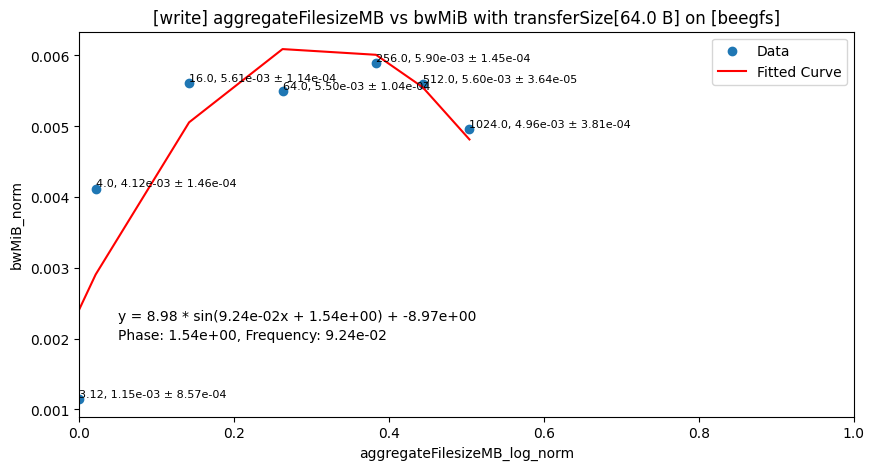

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 6.19818238  0.09995284  1.5448468  -6.19147774]


<Figure size 640x480 with 0 Axes>

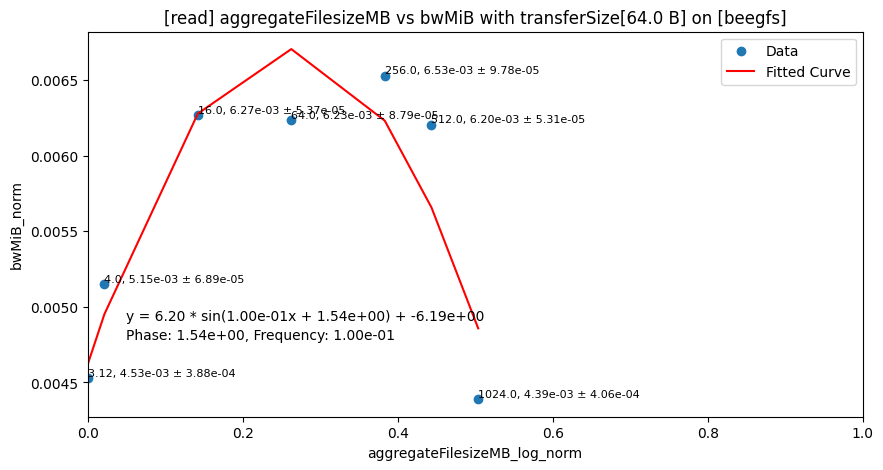

Fitted parameters: [-0.0085982   8.43062361  1.86250604  0.03864306]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

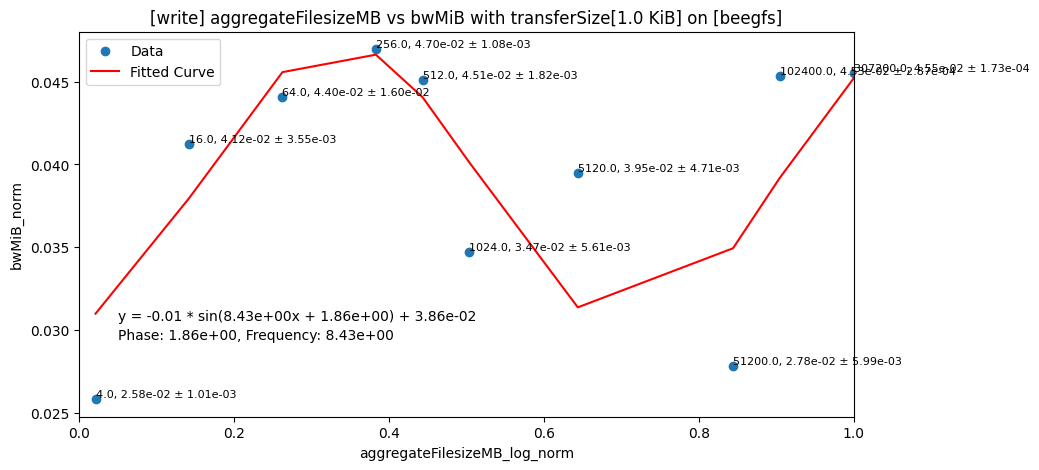

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [-0.01855484  6.6332107   2.80021464  0.04118754]


<Figure size 640x480 with 0 Axes>

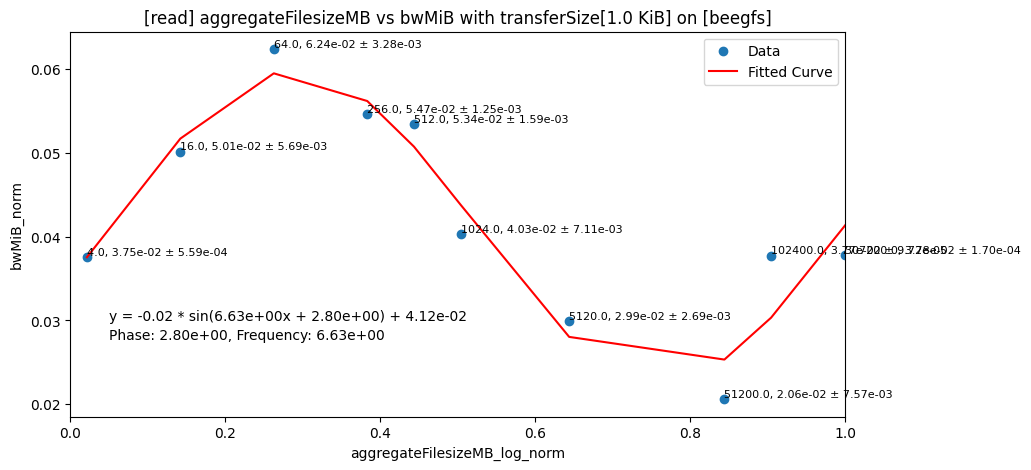

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [-0.02014665  7.56116511  2.37676015  0.04393254]


<Figure size 640x480 with 0 Axes>

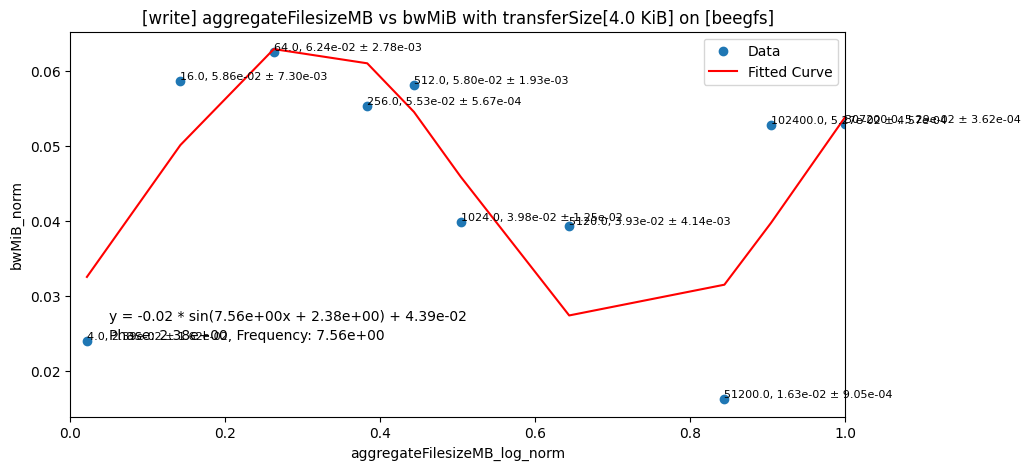

Fitted parameters: [ 0.02625211  6.207413   -0.05938955  0.05017423]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

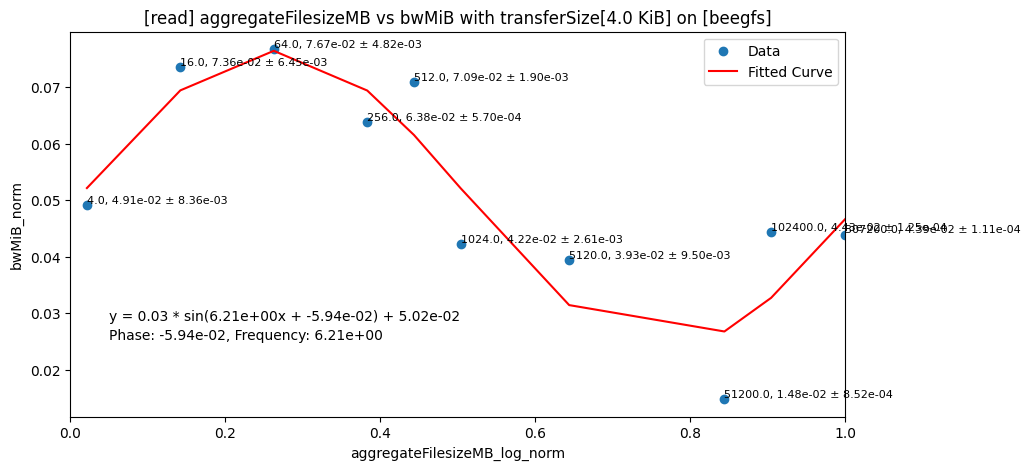

Fitted parameters: [-0.03082897  8.43916089  1.65661775  0.10348613]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

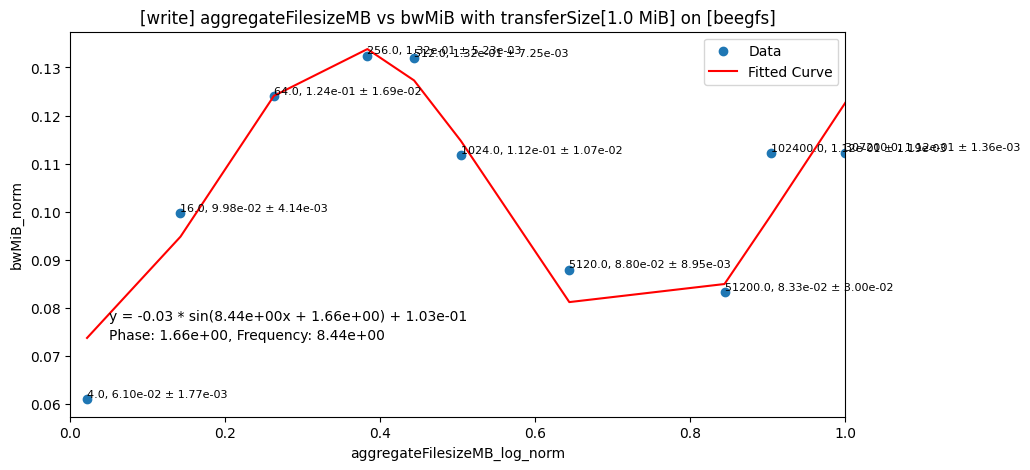

Fitted parameters: [-0.05299406  5.70448999  2.8271362   0.09471757]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

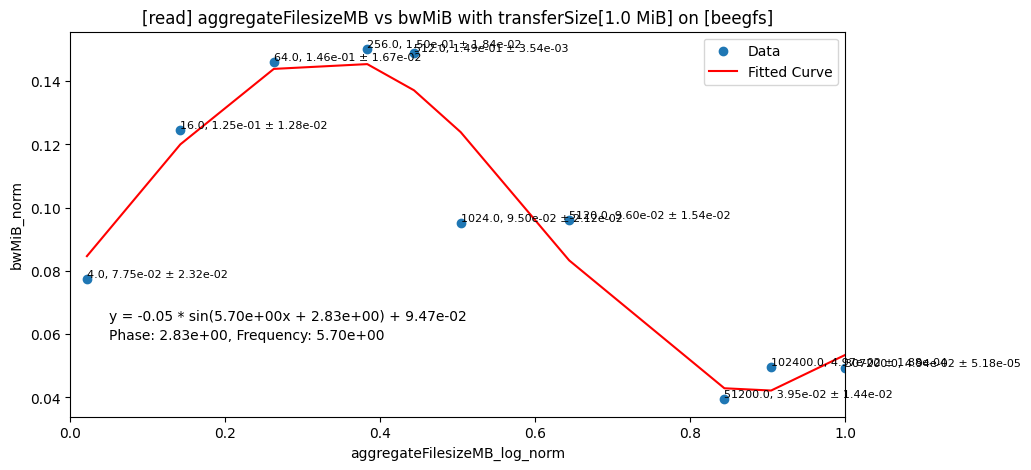

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 7.00037862e+01  5.31887891e-02  7.75846422e+00 -6.98147284e+01]


<Figure size 640x480 with 0 Axes>

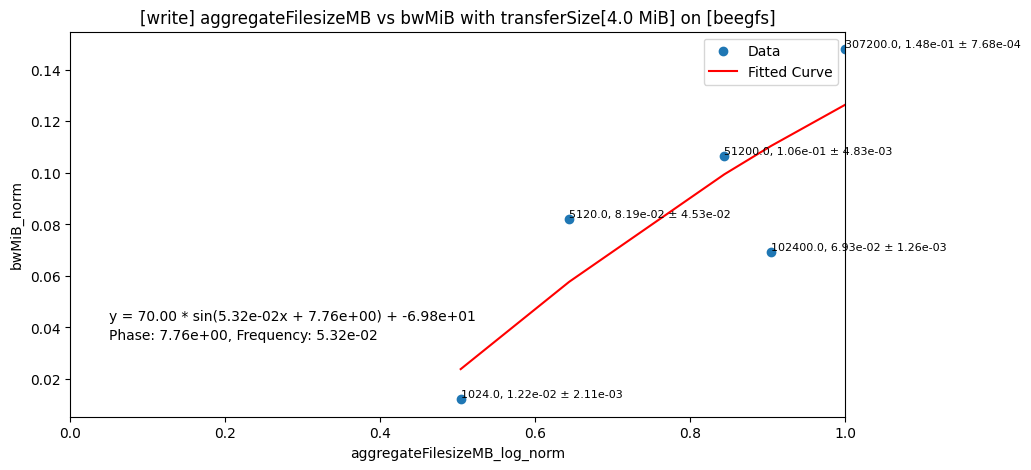

Fitted parameters: [0.04564836 9.04489289 2.82913989 0.08978087]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

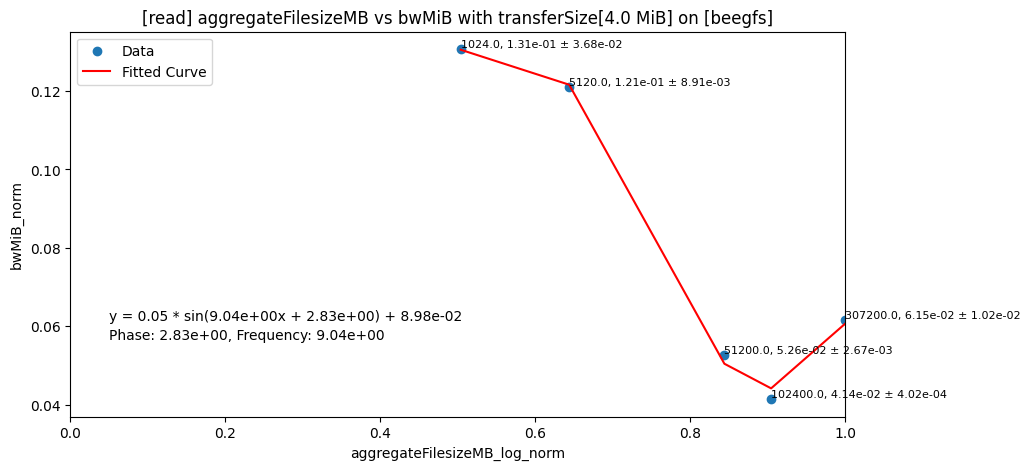

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 9.46280094e+01  4.74270495e-02  7.77863854e+00 -9.44664487e+01]


<Figure size 640x480 with 0 Axes>

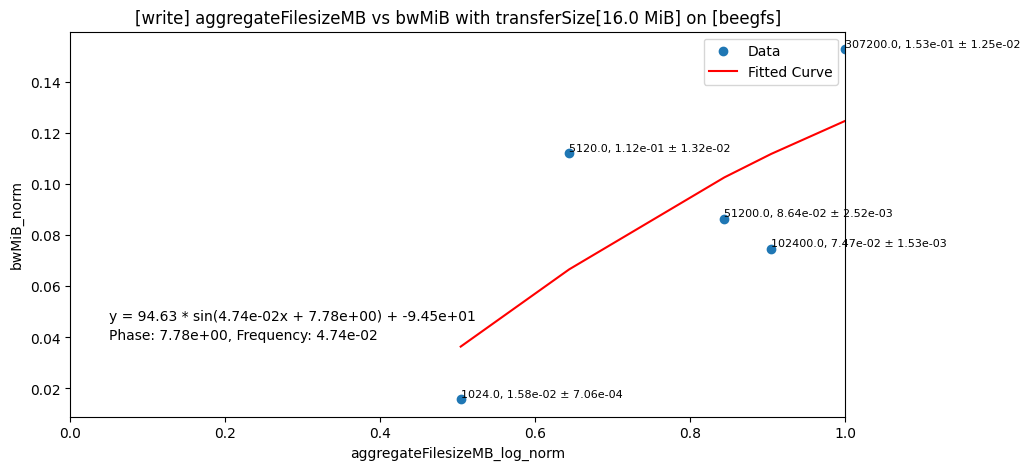

Fitted parameters: [0.0577537  9.1896716  2.85522948 0.10191594]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

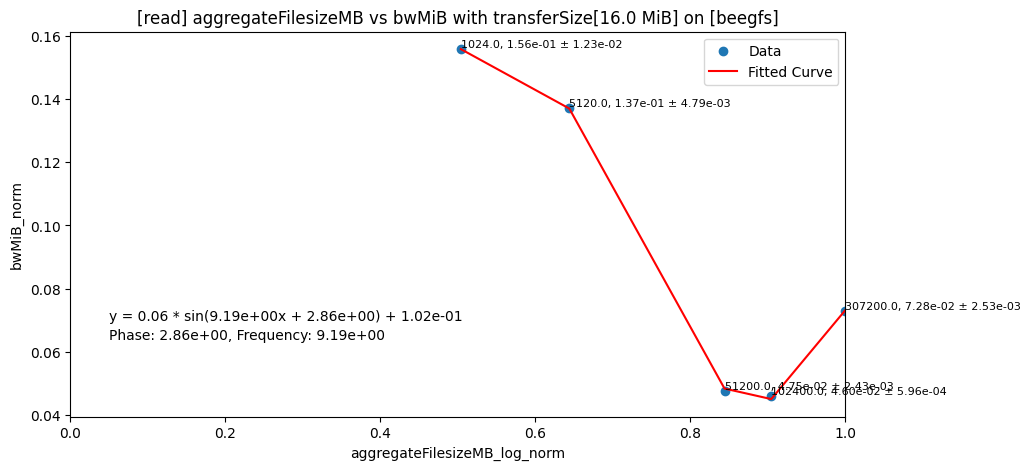

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 6.65398868  0.05886556  7.31802261 -5.77728008]


<Figure size 640x480 with 0 Axes>

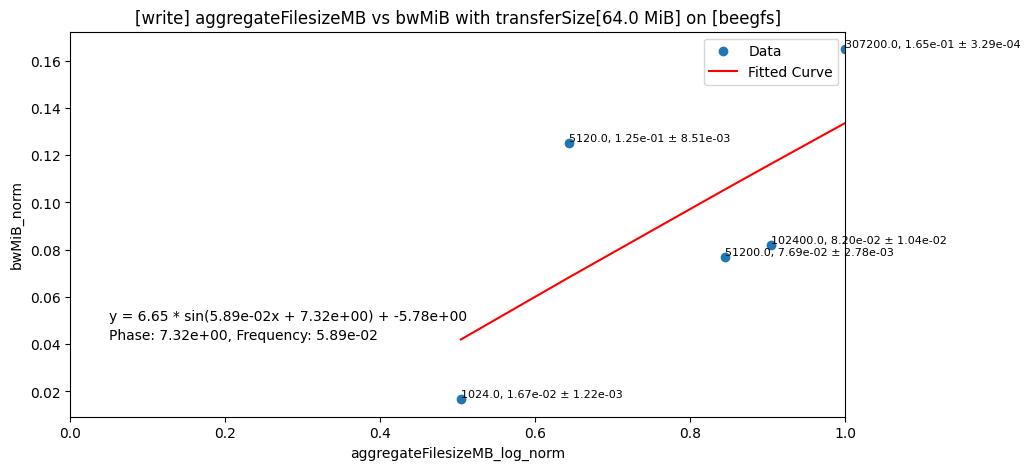

Fitted parameters: [-0.04855179 10.81177317 -1.64614853  0.0910737 ]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

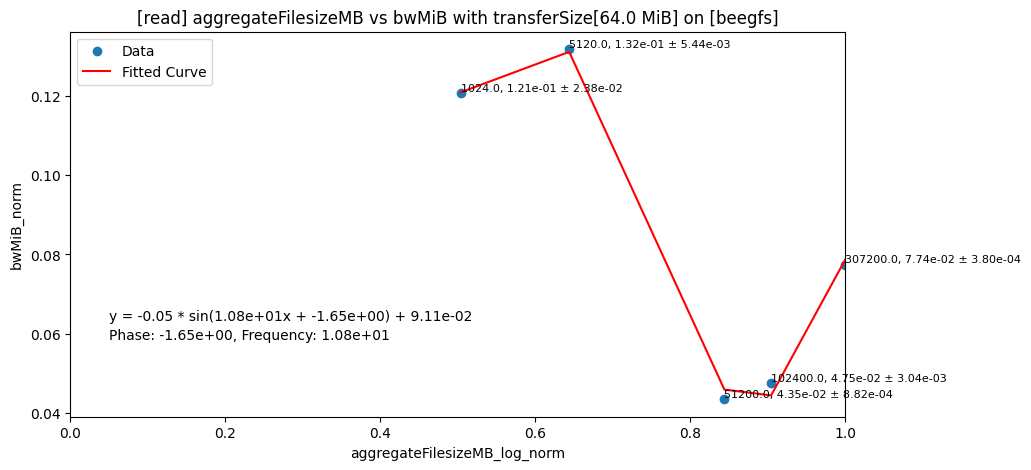

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [8.79184451e+01 4.32784231e-02 4.73970579e+00 8.78476242e+01]


<Figure size 640x480 with 0 Axes>

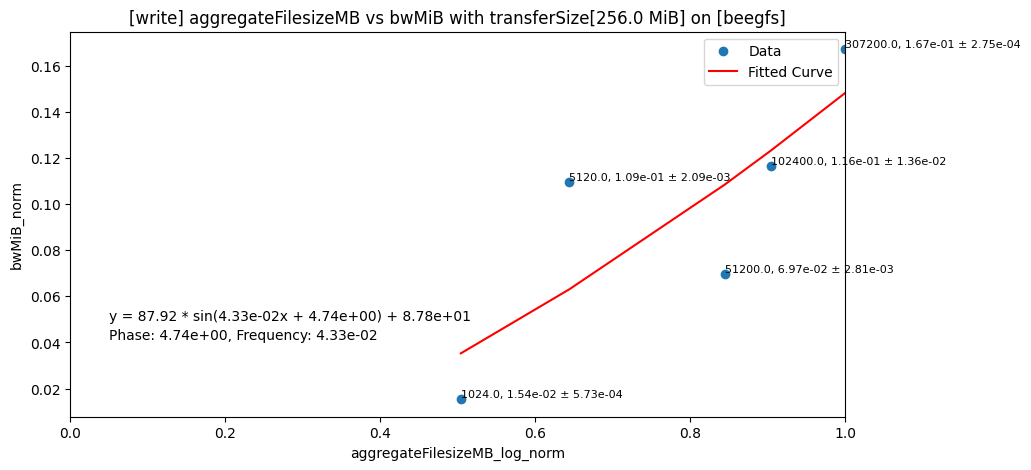

Fitted parameters:

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


 [0.04293851 9.62222869 2.69506786 0.09376619]


<Figure size 640x480 with 0 Axes>

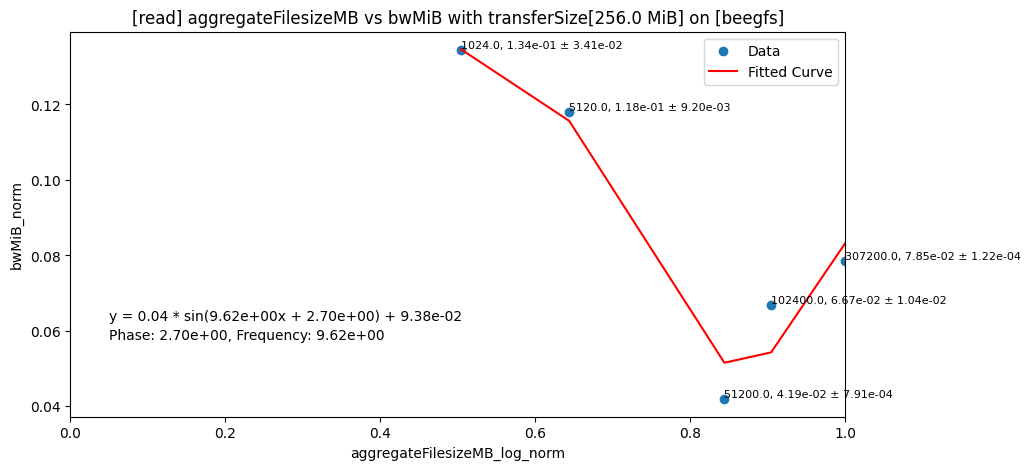

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


Fitted parameters: [ 6.45982835e+01  4.65502763e-02  7.74125344e+00 -6.43054511e+01]


<Figure size 640x480 with 0 Axes>

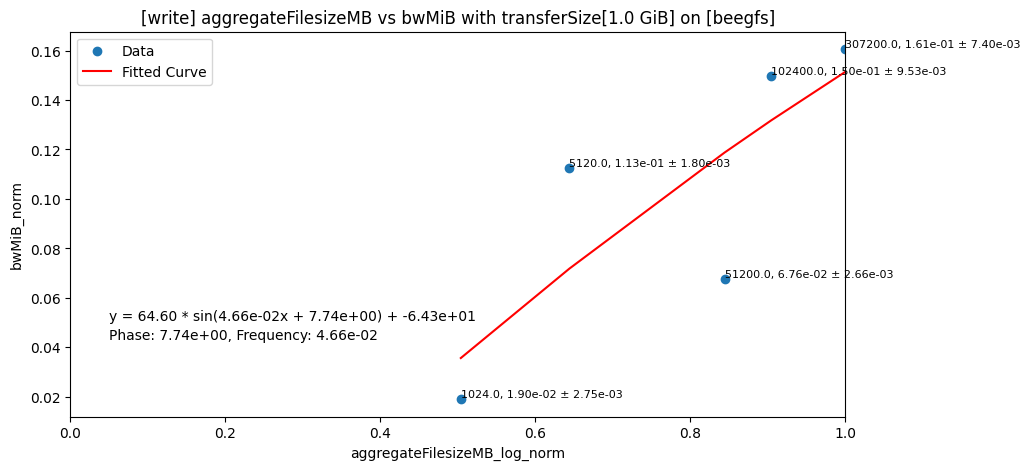

Fitted parameters: [-0.03342057 11.10884809 -1.66007627  0.08517811]


/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/3513952338.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(


<Figure size 640x480 with 0 Axes>

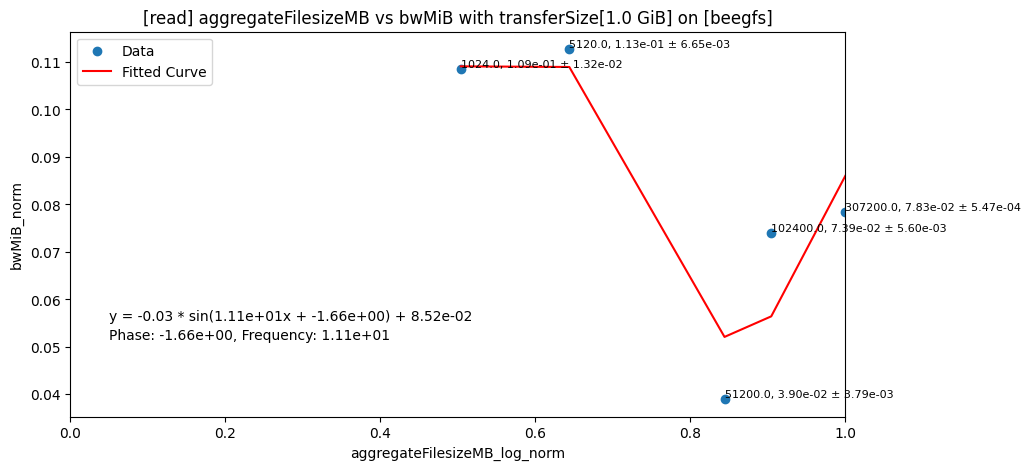

<Figure size 640x480 with 0 Axes>

In [36]:
import os

def analyze_df(scaled_ior_df, numTasks=1):
    # Initialize the DataFrame for storing results
    averaged_bw_df = pd.DataFrame()
    
    # Get storage type from df
    storage_code = scaled_ior_df['storageType'].unique()[0]
    storage_type = decode_store_code(storage_code)

    # Get unique transfer sizes
    xfersizes = sorted(scaled_ior_df['transferSize'].unique().tolist())

    for xfer in xfersizes:
        op_type = [0, 1]
        op_dict = {0: "write", 1: "read"}

        for op in op_type:
            # Filter the DataFrame for specific conditions
            subdf = scaled_ior_df[(scaled_ior_df['numTasks'] == numTasks) &
                                  (scaled_ior_df['transferSize'] == xfer) &
                                  (scaled_ior_df['operation'] == op)]
            
            if not subdf.empty:
                # Perform the aggregation
                ave_bw_df = subdf.groupby('aggregateFilesizeMB_log_norm').apply(
                    lambda group: x_mean_std(group, 'bwMiB_norm')).reset_index()
                # Plotting (as before)
                y_datalabel = [f"{y:.2e} ± {y_std:.2e}" for y, y_std in zip(
                    ave_bw_df['bwMiB_norm_ave'], ave_bw_df['bwMiB_norm_ave_std'])]
                
                save_path="./ior_seq_graph"
                # Make sure the directory exists
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                
                _oscillatory_trend(
                    ave_bw_df['aggregateFilesizeMB_log_norm'], 
                    ave_bw_df['bwMiB_norm_ave'], 
                    x_label="aggregateFilesizeMB_log_norm", 
                    y_label="bwMiB_norm",
                    title=f"[{op_dict[op]}] aggregateFilesizeMB vs bwMiB with transferSize[{byte_size_to_human_size(xfer)}] on [{storage_type}]", 
                    show=True, x_datalabel=sorted(subdf['aggregateFilesizeMB'].unique().tolist()), y_datalabel=y_datalabel,
                    save_path=save_path
                )
                
                

    # return averaged_bw_df

analyze_df(ssd_df, numTasks=1)
analyze_df(beegfs_df, numTasks=1)


# master_ior_df.to_csv("master_ior_df.csv")

In [37]:
# # Select df with std > 27
# ssd_sel_df = ssd_df[ssd_df['bwMiB_ave_std_perc'] > 27]
# beegfs_sel_df = beegfs_df[beegfs_df['bwMiB_ave_std_perc'] > 27]
# print(f"Original SSD DF [{ssd_df.shape}] to [{ssd_sel_df.shape}]")
# print(ssd_sel_df.head(2))
# print(f"Original BeeGFS DF [{beegfs_df.shape}] to [{beegfs_sel_df.shape}]")
# print(beegfs_sel_df.head(2))

# Show the 95th percentile of the bwMiB_ave_std_perc column
print("95th percentile of bwMiB_ave_std_perc column:")
print(f"SSD: {ssd_df['bwMiB_ave_std_perc'].quantile(0.95)}")
print(f"BeeGFS: {beegfs_df['bwMiB_ave_std_perc'].quantile(0.95)}")

# Show the 85th percentile of the bwMiB_ave_std_perc column
print("85th percentile of bwMiB_ave_std_perc column:")
print(f"SSD: {ssd_df['bwMiB_ave_std_perc'].quantile(0.85)}")
print(f"BeeGFS: {beegfs_df['bwMiB_ave_std_perc'].quantile(0.85)}")

# Select sequential read/write operations
ssd_seq_df = ssd_df[ssd_df['numTasks'] == 1]
beegfs_seq_df = beegfs_df[beegfs_df['numTasks'] == 1]
print(f"Sequential SSD DF: {ssd_seq_df.shape}")
print(f"Sequential BeeGFS DF: {beegfs_seq_df.shape}")
# Show the 95th percentile of the bwMiB_ave_std_perc column
print("95th percentile of bwMiB_ave_std_perc column for sequential operations:")
print(f"SSD: {ssd_seq_df['bwMiB_ave_std_perc'].quantile(0.95)}")
print(f"BeeGFS: {beegfs_seq_df['bwMiB_ave_std_perc'].quantile(0.95)}")

# Show the 85th percentile of the bwMiB_ave_std_perc column
print("85th percentile of bwMiB_ave_std_perc column for sequential operations:")
print(f"SSD: {ssd_seq_df['bwMiB_ave_std_perc'].quantile(0.85)}")
print(f"BeeGFS: {beegfs_seq_df['bwMiB_ave_std_perc'].quantile(0.85)}")




95th percentile of bwMiB_ave_std_perc column:
SSD: 18.945794742635464
BeeGFS: 27.9129750374208
85th percentile of bwMiB_ave_std_perc column:
SSD: 10.46696231744693
BeeGFS: 15.339444898049969
Sequential SSD DF: (378, 17)
Sequential BeeGFS DF: (372, 17)
95th percentile of bwMiB_ave_std_perc column for sequential operations:
SSD: 18.740854012679655
BeeGFS: 28.129782620465356
85th percentile of bwMiB_ave_std_perc column for sequential operations:
SSD: 9.50907146832952
BeeGFS: 14.430386582458702


In [38]:
# Select sequential read/write that has bwMiB_ave_std_perc > perc
perc = 20
ssd_seq_sel_df = ssd_seq_df[ssd_seq_df['bwMiB_ave_std_perc'] > perc]
beegfs_seq_sel_df = beegfs_seq_df[beegfs_seq_df['bwMiB_ave_std_perc'] > perc]
print(f"Sequential SSD DF with bwMiB_ave_std_perc > {perc}: {ssd_seq_sel_df.shape}")
print(ssd_seq_sel_df)
print(f"Sequential BeeGFS DF with bwMiB_ave_std_perc > {perc}: {beegfs_seq_sel_df.shape}")
print(beegfs_seq_sel_df)


Sequential SSD DF with bwMiB_ave_std_perc > 20: (15, 17)
      operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
727         0.0           0.0     4194304.0               5120.0       1.0   
728         0.0           0.0     4194304.0               5120.0       1.0   
729         0.0           0.0     4194304.0             102400.0       1.0   
730         0.0           0.0     4194304.0              51200.0       1.0   
731         0.0           0.0     4194304.0               1024.0       1.0   
732         0.0           0.0     4194304.0              51200.0       1.0   
733         0.0           0.0     4194304.0               1024.0       1.0   
734         0.0           0.0     4194304.0             102400.0       1.0   
735         0.0           0.0     4194304.0             102400.0       1.0   
736         0.0           0.0     4194304.0               5120.0       1.0   
737         0.0           0.0     4194304.0               1024.0       1.0   
738    

In [39]:
def merge_by_test_param(ssd_df, beegfs_df):
    allColumns = ssd_df.columns
    print(f"All columns: {allColumns}")
    # Compare and find the row with only storage_type and bwMiB columns different but others are the same
    # Merge the dataframes on columns other than 'storageType' and 'bwMiB'
    merge_columns = ['randomOffset', 'transferSize', 'aggregateFilesizeMB',
       'numTasks', 'numNodes', 'tasksPerNode']
    merged_df = pd.merge(ssd_df, beegfs_df, on=merge_columns, suffixes=('_ssd', '_beegfs'))

    # Remove columns storageType_ssd and storageType_beegfs
    merged_df.drop(['storageType_ssd', 'storageType_beegfs'], axis=1, inplace=True)
    # # Remove one 'operation_ssd' column, rename the other to 'operation'
    merged_df.rename(columns={'operation_ssd': 'operation'}, inplace=True)
    
    # Compare 'bwMiB' values and add 'selectStorage' column
    merged_df['selectStorage'] = merged_df.apply(lambda row: 0 if row['bwMiB_ssd'] > row['bwMiB_beegfs'] else 1, axis=1)


    print(merged_df.head(5))
    # print shaoe
    print(f"merged_df.shape: {merged_df.shape}")
    print(f"ssd_df.shape: {ssd_df.shape}")
    print(f"beegfs_df.shape: {beegfs_df.shape}")

    return merged_df


master_ior_df = merge_by_test_param(ssd_df, beegfs_df)


allColumns = master_ior_df.columns

# master_ior_df = master_ior_df.group(allColumns).first()
master_ior_df = master_ior_df.drop_duplicates(subset=allColumns)

# Show 5 rows with selectStorage = 0
print(f"Rows with selectStorage = {decode_store_code(0)}")
print(master_ior_df[master_ior_df['selectStorage'] == 0].head(5))

# Show 5 rows with selectStorage = 1
print(f"Rows with selectStorage = {decode_store_code(1)}")
print(master_ior_df[master_ior_df['selectStorage'] == 1].head(5))

print("Shape of master_ior_df: ", master_ior_df.shape)

All columns: Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
       'numTasks', 'totalTime', 'numNodes', 'tasksPerNode', 'bwMiB',
       'storageType', 'bwMiB_ave', 'bwMiB_ave_std', 'bwMiB_ave_std_perc',
       'aggregateFilesizeMB_log', 'transferSize_log',
       'aggregateFilesizeMB_log_norm', 'bwMiB_norm'],
      dtype='object')
   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        0.0           0.0          64.0               1024.0       1.0   
1        0.0           0.0          64.0               1024.0       1.0   
2        0.0           0.0          64.0               1024.0       1.0   
3        0.0           0.0          64.0               1024.0       1.0   
4        0.0           0.0          64.0               1024.0       1.0   

   totalTime_ssd  numNodes  tasksPerNode  bwMiB_ssd  bwMiB_ave_ssd  ...  \
0        19.2664       1.0           1.0    53.1495        52.8634  ...   
1        19.2664       1.0           1

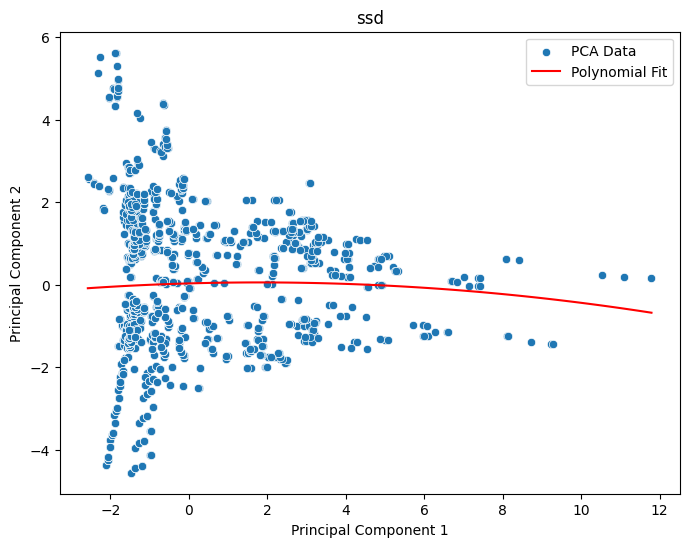

Polynomial fit parameters: a=-0.007346379088164268, b=0.02643515336701674, c=0.030738221450037462
Reconstruction error (MSE): 0.395303141335983
Explained variance by principal components: [0.29886654 0.2211225 ]


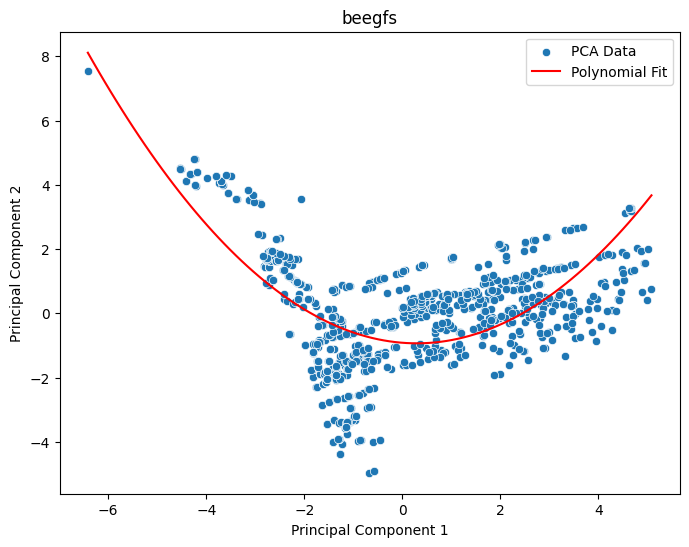

Polynomial fit parameters: a=0.2008099888845416, b=-0.11841551519046112, c=-0.9176170082658155
Reconstruction error (MSE): 0.36820447086705704
Explained variance by principal components: [0.32639846 0.22649611]


/Users/mengtang/script/linux_resource_detect/venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


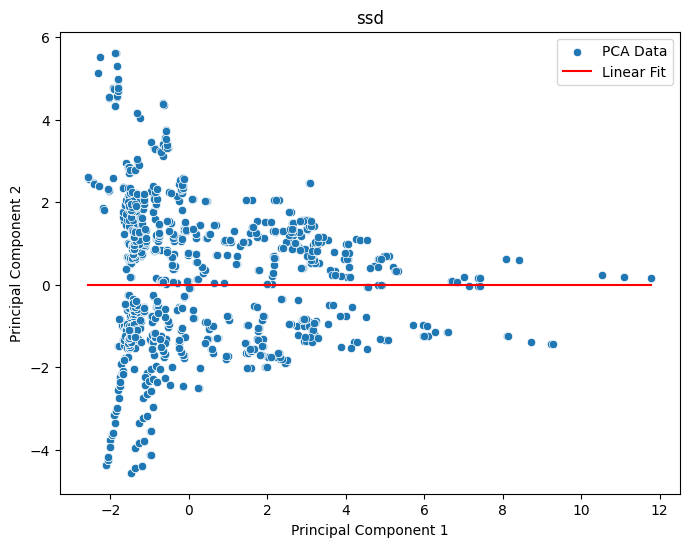

Linear fit parameters: intercept=1.1891928631968203e-16, slope=3.0836985606509583e-16
Reconstruction error (MSE): 0.395303141335983
Explained variance by principal components: [0.29886654 0.2211225 ]


/Users/mengtang/script/linux_resource_detect/venv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


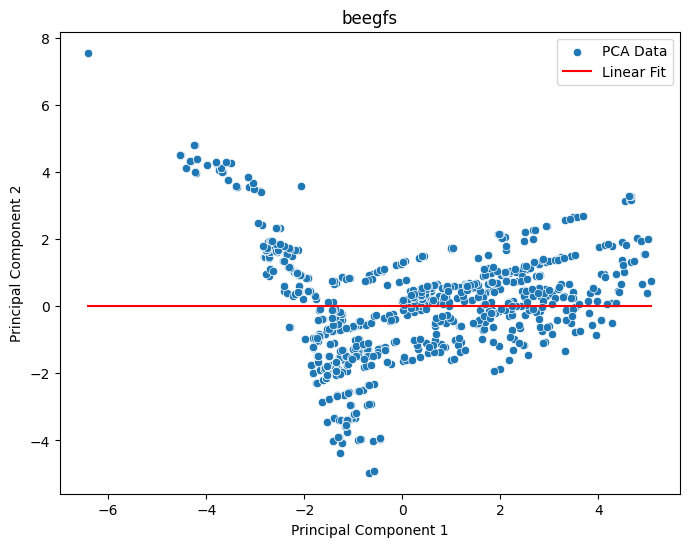

Linear fit parameters: intercept=-3.136383990295027e-33, slope=1.0019934480582026e-16
Reconstruction error (MSE): 0.36820447086705704
Explained variance by principal components: [0.32639846 0.22649611]


In [40]:
# select only storage type of 0
_polynomial_fit_pca(ssd_df, title="ssd")
_polynomial_fit_pca(beegfs_df, title="beegfs")
_linear_fit_pca(ssd_df, title="ssd")
_linear_fit_pca(beegfs_df, title="beegfs")



In [41]:
# Compute read/write ratios within each group
def calculate_ratios(group):
    write_df = group[group['operation'] == 0]
    read_df = group[group['operation'] == 1]

    # Initialize the ratio results
    result = {"RWR_ssd": 0, "RWR_beegfs": 0}

    # Check for non-empty data in both read and write DataFrames
    if not write_df.empty and not read_df.empty:
        result['RWR_ssd'] = read_df['bwMiB_ave_ssd'].mean() / write_df['bwMiB_ave_ssd'].mean() if write_df['bwMiB_ave_ssd'].mean() != 0 else 0
        result['RWR_beegfs'] = read_df['bwMiB_ave_beegfs'].mean() / write_df['bwMiB_ave_beegfs'].mean() if write_df['bwMiB_ave_beegfs'].mean() != 0 else 0

    return pd.Series(result)

# Group by 'transferSize', 'aggregateFilesizeMB', 'numTasks' and apply the ratio function
master_ior_df[['RWR_ssd', 'RWR_beegfs']] = master_ior_df.groupby(['transferSize', 'aggregateFilesizeMB', 'numTasks']).apply(calculate_ratios).reset_index(drop=True)

# Show the DataFrame with the new columns
print(master_ior_df.head(5))

# Save the merged DataFrame to a CSV file
master_ior_df.to_csv("master_ior_df.csv")

   operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
0        0.0           0.0          64.0               1024.0       1.0   
1        0.0           0.0          64.0               1024.0       1.0   
2        0.0           0.0          64.0               1024.0       1.0   
3        0.0           0.0          64.0               1024.0       1.0   
4        0.0           0.0          64.0               1024.0       1.0   

   totalTime_ssd  numNodes  tasksPerNode  bwMiB_ssd  bwMiB_ave_ssd  ...  \
0        19.2664       1.0           1.0    53.1495        52.8634  ...   
1        19.2664       1.0           1.0    53.1495        52.8634  ...   
2        19.2664       1.0           1.0    53.1495        52.8634  ...   
3        19.2664       1.0           1.0    53.1495        52.8634  ...   
4        19.2664       1.0           1.0    53.1495        52.8634  ...   

   bwMiB_ave_beegfs  bwMiB_ave_std_beegfs  bwMiB_ave_std_perc_beegfs  \
0        112.166900       

/var/folders/t1/j5nks1f97pzdzx63f2_4_65m0000gn/T/ipykernel_31614/1118829823.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_ior_df[['RWR_ssd', 'RWR_beegfs']] = master_ior_df.groupby(['transferSize', 'aggregateFilesizeMB', 'numTasks']).apply(calculate_ratios).reset_index(drop=True)


In [43]:
# Show rows with RWR_ssd is nan
print("Rows with nan RWR_ssd:")
nan_rwr_df = master_ior_df[master_ior_df['RWR_ssd'].isna()]
print(nan_rwr_df.shape)
# Show the unique operations in the DataFrame
print("Unique operations:")
print(master_ior_df['operation'].unique())


Rows with nan RWR_ssd:
(4652, 29)
Unique operations:
[0. 1.]


In [48]:
# Show the number range of RWR_beegfs
print("RWR_beegfs range:")
print(master_ior_df['RWR_beegfs'].describe())
print()

# Show the number range of RWR_ssd
print("RWR_ssd range:")
print(master_ior_df['RWR_ssd'].describe())
# Show the rows with RWR_ssd.max
max_rwr_ssd = master_ior_df[master_ior_df['RWR_ssd'] == master_ior_df['RWR_ssd'].max()]
print("Rows with RWR_ssd.max:")
print(max_rwr_ssd)

RWR_beegfs range:
count    136.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: RWR_beegfs, dtype: float64
RWR_ssd range:
count    136.000000
mean      57.283265
std       81.681417
min        2.625515
25%        7.652255
50%       19.773238
75%       68.190825
max      471.158933
Name: RWR_ssd, dtype: float64
Rows with RWR_ssd.max:
    operation  randomOffset  transferSize  aggregateFilesizeMB  numTasks  \
53        0.0           0.0          64.0                 64.0       1.0   

    totalTime_ssd  numNodes  tasksPerNode  bwMiB_ssd  bwMiB_ave_ssd  ...  \
53         1.2108       1.0           1.0    52.8566      52.649167  ...   

    bwMiB_ave_beegfs  bwMiB_ave_std_beegfs  bwMiB_ave_std_perc_beegfs  \
53          126.4301              0.982919                   0.777441   

    aggregateFilesizeMB_log_beegfs  transferSize_log_beegfs  \
53                        4.158883                 4.158883   

    aggregateFilesize

RWR_beegfs range:
count    136.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: RWR_beegfs, dtype: float64
